# Laboratorio 13: Distribuciones de probabilidad y Ley Débil de los Grandes Números

**Materia:** FS0432 – Física Computacional
**Fecha:** 15 de junio de 2026

## Objetivo
Estudiar las distribuciones uniforme, exponencial y normal, verificar sus valores teóricos y comprobar la Ley Débil de los Grandes Números mediante simulaciones.

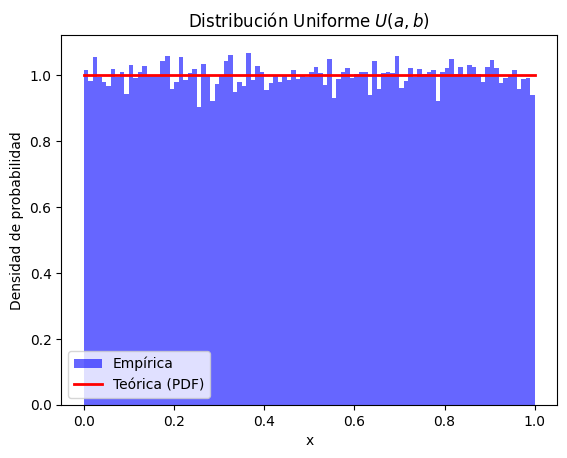

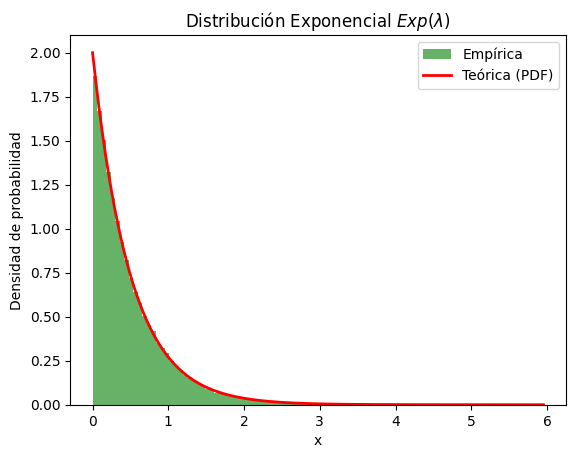

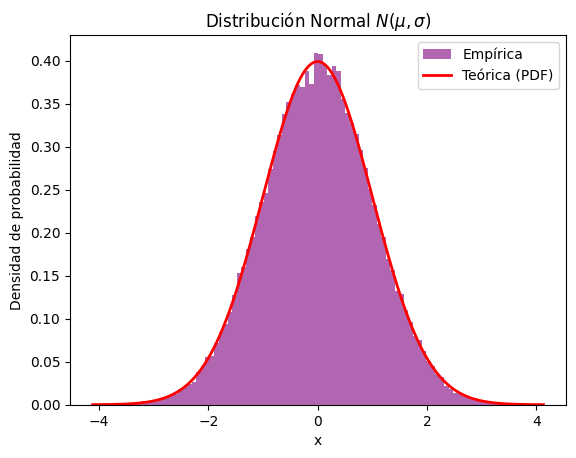

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1213)  # Semilla aleatoria
N = 100_000          # Tamaño de la muestra
bins = 100          # Cantidad de bines

# Parámetros por distribución
a, b = 0, 1         # Uniforme
lam = 2             # Exponencial (lambda)
mu, sigma = 0, 1    # Gaussiana (media y desviación estándar)

# ==========================================
# 1. DISTRIBUCIÓN UNIFORME
# ==========================================

data_uni = np.random.uniform(a, b, size=N)

plt.hist(data_uni, bins=bins, density=True, alpha=0.6, color='blue', label='Empírica')

x_uni = np.linspace(a, b, 1000)
pdf_uni = np.ones(1000) / (b - a)
plt.plot(x_uni, pdf_uni, 'r-', lw=2, label='Teórica (PDF)')

plt.title('Distribución Uniforme $U(a, b)$')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.show()

# ==========================================
# 2. DISTRIBUCIÓN EXPONENCIAL
# ==========================================

# El parmetro es scale, no lambda. Entonces scale = 1/lambda
data_exp = np.random.exponential(scale=1.0/lam, size=N)

plt.hist(data_exp, bins=bins, density=True, alpha=0.6, color='green', label='Empírica')

x_exp = np.linspace(0, max(data_exp), 1000)
pdf_exp = lam * np.exp(-lam * x_exp)
plt.plot(x_exp, pdf_exp, 'r-', lw=2, label='Teórica (PDF)')


plt.title('Distribución Exponencial $Exp(\\lambda)$')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.show()

# ==========================================
# 3. DISTRIBUCIÓN GAUSSIANA (NORMAL)
# ==========================================

data_gauss = np.random.normal(loc=mu, scale=sigma, size=N)

plt.hist(data_gauss, bins=bins, density=True, alpha=0.6, color='purple', label='Empírica')
x_gauss = np.linspace(min(data_gauss), max(data_gauss), 1000)

pdf_gauss = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_gauss - mu) / sigma)**2)
plt.plot(x_gauss, pdf_gauss, 'r-', lw=2, label='Teórica (PDF)')


plt.title('Distribución Normal $N(\\mu, \\sigma)$')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.show()

---
## 1. Derivaciones analíticas

### Distribución Uniforme $U(a,b)$
Función de densidad:
$$p(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$

- **Valor esperado:**
$$
E[X] = \int_{a}^{b} x \cdot \frac{1}{b-a} dx = \frac{1}{b-a} \left[ \frac{x^2}{2} \right]_a^b = \frac{b^2 - a^2}{2(b-a)} = \frac{a+b}{2}
$$

- **Varianza:**
Primero calculamos $E[X^2]$:
$$
E[X^2] = \int_{a}^{b} x^2 \cdot \frac{1}{b-a} dx = \frac{b^3 - a^3}{3(b-a)} = \frac{a^2 + ab + b^2}{3}
$$
$$
\text{Var}(X) = E[X^2] - (E[X])^2 = \frac{a^2 + ab + b^2}{3} - \left( \frac{a+b}{2} \right)^2 = \frac{(b-a)^2}{12}
$$

---

### Distribución Exponencial $Exp(\lambda)$
Función de densidad:
$$p(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

- **Valor esperado:**
Por integración por partes:
$$
E[X] = \int_{0}^{\infty} x \lambda e^{-\lambda x} dx = -x e^{-\lambda x} \bigg|_0^\infty + \int_{0}^{\infty} e^{-\lambda x} dx = 0 + \frac{1}{\lambda} = \frac{1}{\lambda}
$$

- **Varianza:**
$$
E[X^2] = \int_{0}^{\infty} x^2 \lambda e^{-\lambda x} dx = \frac{2}{\lambda^2}
$$
$$
\text{Var}(X) = E[X^2] - (E[X])^2 = \frac{2}{\lambda^2} - \frac{1}{\lambda^2} = \frac{1}{\lambda^2}
$$

In [ ]:
# ======================================
# 4. Ley Débil de los Grandes Números
# ======================================

# Valores de N que pide el profesor
N_lista = [10**1, 10**2, 10**3, 10**4, 10**5, 10**6]

# Valores teóricos
mu_uni = (a + b) / 2
var_uni = (b - a)**2 / 12

mu_exp = 1 / lam
var_exp = 1 / (lam**2)

mu_norm = mu
var_norm = sigma**2

# Guardamos resultados
medias_uni = []
var_emp_uni = []

medias_exp = []
var_emp_exp = []

medias_norm = []
var_emp_norm = []

# Recorremos cada tamaño de muestra
for n in N_lista:
    # Uniforme
    muestra1 = np.random.uniform(a, b, size=n)
    medias_uni.append(np.mean(muestra1))
    var_emp_uni.append(np.var(muestra1))

    # Exponencial
    muestra2 = np.random.exponential(scale=1/lam, size=n)
    medias_exp.append(np.mean(muestra2))
    var_emp_exp.append(np.var(muestra2))

    # Normal
    muestra3 = np.random.normal(loc=mu, scale=sigma, size=n)
    medias_norm.append(np.mean(muestra3))
    var_emp_norm.append(np.var(muestra3))

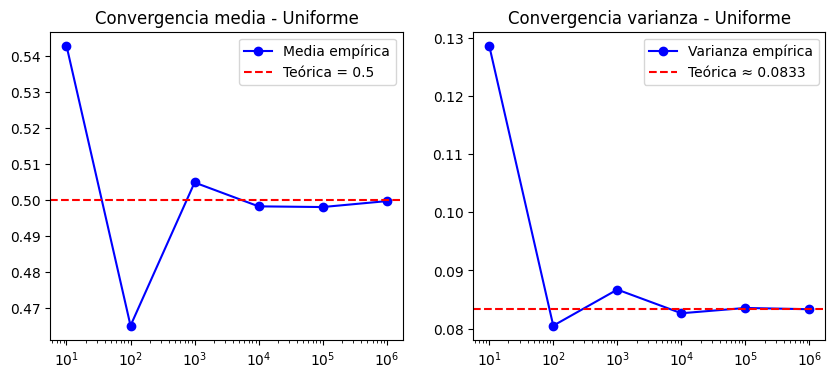

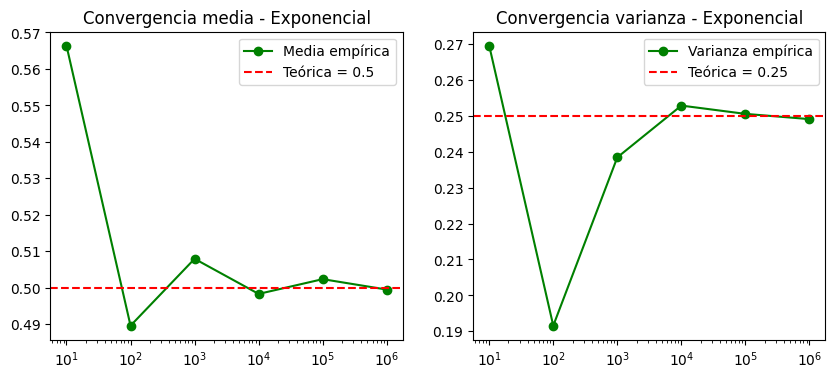

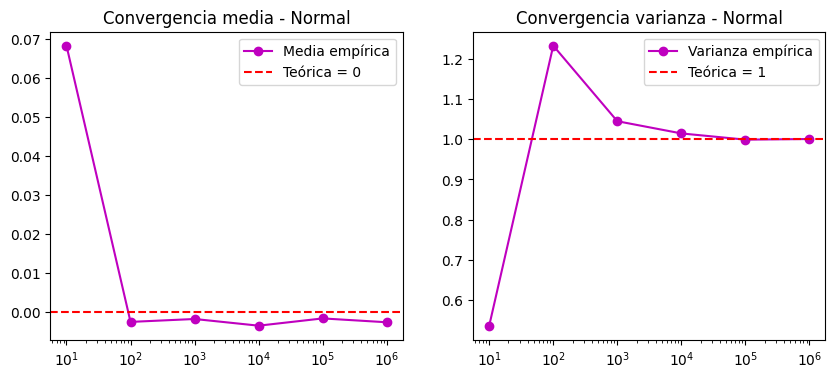

In [ ]:
# Gráficos Uniforme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(N_lista, medias_uni, 'bo-', label='Media empírica')
ax1.axhline(mu_uni, color='red', linestyle='--', label='Teórica = 0.5')
ax1.set_xscale('log')
ax1.set_title('Convergencia media - Uniforme')
ax1.legend()

ax2.plot(N_lista, var_emp_uni, 'bo-', label='Varianza empírica')
ax2.axhline(var_uni, color='red', linestyle='--', label='Teórica ≈ 0.0833')
ax2.set_xscale('log')
ax2.set_title('Convergencia varianza - Uniforme')
ax2.legend()
plt.show()

# Gráficos Exponencial
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(N_lista, medias_exp, 'go-', label='Media empírica')
ax1.axhline(mu_exp, color='red', linestyle='--', label='Teórica = 0.5')
ax1.set_xscale('log')
ax1.set_title('Convergencia media - Exponencial')
ax1.legend()

ax2.plot(N_lista, var_emp_exp, 'go-', label='Varianza empírica')
ax2.axhline(var_exp, color='red', linestyle='--', label='Teórica = 0.25')
ax2.set_xscale('log')
ax2.set_title('Convergencia varianza - Exponencial')
ax2.legend()
plt.show()

# Gráficos Normal
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(N_lista, medias_norm, 'mo-', label='Media empírica')
ax1.axhline(mu_norm, color='red', linestyle='--', label='Teórica = 0')
ax1.set_xscale('log')
ax1.set_title('Convergencia media - Normal')
ax1.legend()

ax2.plot(N_lista, var_emp_norm, 'mo-', label='Varianza empírica')
ax2.axhline(var_norm, color='red', linestyle='--', label='Teórica = 1')
ax2.set_xscale('log')
ax2.set_title('Convergencia varianza - Normal')
ax2.legend()
plt.show()

---
## Conclusión
Se puede ver que al aumentar el tamaño de la muestra, los valores calculados se acercan cada vez más al valor teórico. Esto cumple con la Ley Débil de los Grandes Números.